# 01 — MNIST Linear Autoencoder

We train an unsupervised **linear autoencoder** on MNIST and use its **latent codes** visualization: we scatter the latent space and color by ground-truth labels to see that the AE learns a representation that clusters by digit.

#### Set up Drive and dependencies when running on Google Colab
Othersie, skip the following two cells.

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# change the working directory
repo_url = "https://github.com/pjyazdian/VQVAE-INN-Workshop.git"
repo_name = "VQVAE-INN-Workshop"
repo_path = f"/content/drive/MyDrive/{repo_name}"
%cd {repo_path}

## Load packages and helpers

In [1]:
import torch
import numpy as np
from utils import (
    get_device,
    get_mnist_loaders,
    LinearAE,
    AETrainer,
    scatter_latent,
    plot_reconstructions,
)

/localhome/pjomeyaz/anaconda3/envs/motionagent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load MNIST

In [2]:
train_loader, val_loader = get_mnist_loaders(root="./data", batch_size=32)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 1875, Val batches: 313


## Create model and trainer

In [3]:
device = get_device()
latent_dim = 32  # use 2 for direct 2D scatter; use 32 and let scatter_latent run t-SNE
model = LinearAE(latent_dim=latent_dim)
trainer = AETrainer(model, train_loader, val_loader, learning_rate=1e-3, device=device)

## Train

In [4]:
n_epochs = 10
trainer.run(n_epochs)

====> Epoch: 1 Train loss: 0.2204
====> Epoch: 1 Val loss: 0.1928


====> Epoch: 2 Train loss: 0.1852
====> Epoch: 2 Val loss: 0.1690


====> Epoch: 3 Train loss: 0.1649
====> Epoch: 3 Val loss: 0.1553


====> Epoch: 4 Train loss: 0.1521
====> Epoch: 4 Val loss: 0.1452


====> Epoch: 5 Train loss: 0.1433
====> Epoch: 5 Val loss: 0.1392


====> Epoch: 6 Train loss: 0.1371
====> Epoch: 6 Val loss: 0.1314


====> Epoch: 7 Train loss: 0.1319
====> Epoch: 7 Val loss: 0.1311


====> Epoch: 8 Train loss: 0.1281
====> Epoch: 8 Val loss: 0.1247


====> Epoch: 9 Train loss: 0.1249
====> Epoch: 9 Val loss: 0.1217


====> Epoch: 10 Train loss: 0.1222
====> Epoch: 10 Val loss: 0.1180


## Latent space clustering (colored by digit)

We encode the validation set and scatter the latent codes. If latent dim > 2, t-SNE is applied so we can visualize.

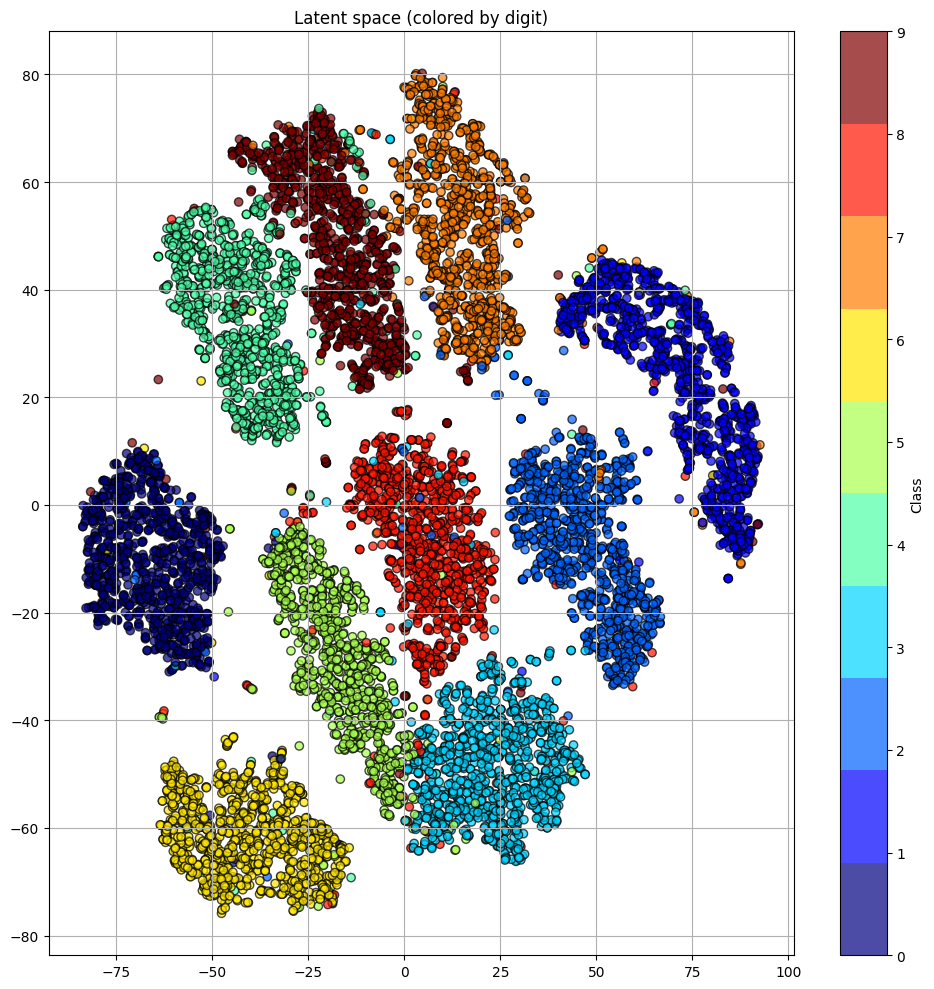

In [5]:
model.eval()
latents, labels_list = [], []
with torch.no_grad():
    for data, labels in val_loader:
        data = data.to(device).view(data.size(0), -1)
        z = model.encode(data)
        latents.append(z.cpu().numpy())
        labels_list.append(labels.numpy())
latents = np.concatenate(latents, axis=0)
labels_all = np.concatenate(labels_list, axis=0)
scatter_latent(latents, labels_all, use_tsne=True, title="Latent space (colored by digit)")

## Reconstructions

Original vs reconstructed images for a few validation samples.

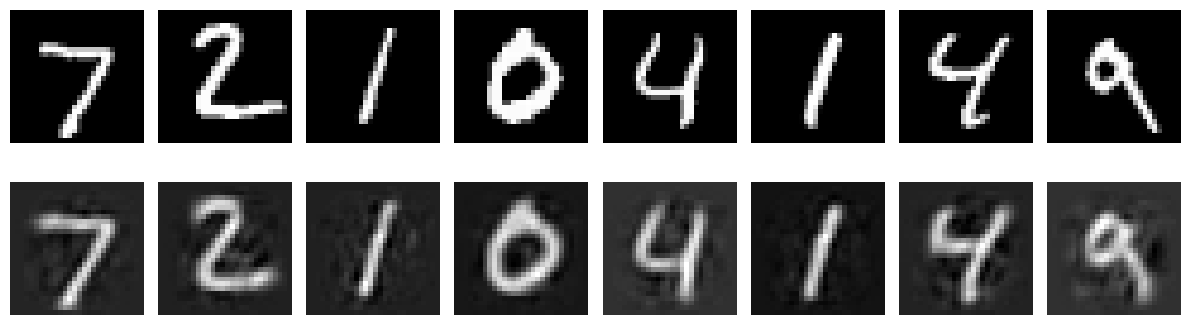

In [8]:
model.eval()
with torch.no_grad():
    data, _ = next(iter(val_loader))
    data = data.to(device).view(data.size(0), -1)
    recon = model(data)
    # z = model.encode(data)
    # recon = model.decode(z)
plot_reconstructions(data, recon, n=8)
